## 各船の船舶ログから偏流を計算するまでの流れ
1. 複数のログファイルをFileConection.ipynbで１つのファイルにする
1. S1-ShipLogToS1でファイルから必要な情報を抜き出す
1. このファイル(環境省の船舶ログから偏流)で各船の偏流を計算

## import files

In [30]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
from tqdm import tqdm
import pickle as pkl
import math
import os 
import os.path as osp

from utils import *
from kf_params import *

## 関数の定義

In [31]:
def latlon_to_mesh_df(lat, lon, deg_per_mesh=1/36, size=[1050, 1191], latlon_range=[20-1/36, 117-1/36]):
    # lat, lon -> [lon, lat]
    grid0 = ((lon-latlon_range[1]).astype(int)/deg_per_mesh)
    grid1 = ((lat-latlon_range[0]).astype(int)/deg_per_mesh)
    grid0[grid0 < 0] = -1
    grid0[grid0 > size[0]] = -1
    grid1[grid1 < 0] = -1
    grid1[grid1 > size[1]] = -1
    return grid0, grid1

def dms_to_deg_df(x):
    deg = x // 100
    mit = (x - deg*100).astype(int)
    sec = (x - (x).astype(int))*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60 + sec/3600

def mean_ground_speed(dt, lat1, lon1, lat2, lon2):
    
    lat1 = dms_to_deg(lat1)
    lon1 = dms_to_deg(lon1)
    
    lat2 = dms_to_deg(lat2)
    lon2 = dms_to_deg(lon2)
    
    #print(f"{lat1}, {lon1}")
    #print(f"{lat2}, {lon2}")
    dist, deg = dist_deg_latlon(lat1, lon1, lat2, lon2)
    speed = dist/dt
    return ((lat1+lat2)/2, (lon1+lon2)/2), (speed, deg)

def dist_deg_latlon(lat1, lon1, lat2, lon2):
    from geopy.distance import geodesic
    res = geodesic((lat1, lon1), (lat2, lon2))
    # 方位角を計算
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    delta_lon = lon2_rad - lon1_rad
    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
    bearing = math.degrees(math.atan2(y, x))

    # 0から360度の範囲に調整
    bearing = (bearing + 360) % 360
    return res.meters, bearing

def dms_to_deg(x):
    deg = x // 100
    mit = int(x - deg*100)
    sec = (x - int(x))*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60 + sec/3600

def deg_to_rat(deg):
    return (-deg-90)*np.pi/180

## データの読み込みとデータ操作

In [93]:
dt_year = 2015
dt_month = 12
dt_day = 30

log_data = None
path_log = "./data/shipLog/中春"
filename = f"中春丸FileOut{dt_year}{dt_month}{dt_day}.slog1"
log = pd.read_csv(osp.join(path_log, filename), encoding="cp932", header=None)
if log_data==None:
    log_data = log
else:
    log_data = pd.concat([log_data, log])
log_data.columns = ["UTC", "NMEA", "data1", "data2"]

In [94]:
log_data

,UTC,NMEA,data1,data2
0,2015/12/29 15:00:00,VBW,13.200,-999.000
1,2015/12/29 15:00:00,GGA,3429.563,13814.650
2,2015/12/29 15:00:00,VTG,266.500,12.900
3,2015/12/29 15:00:00,HDT,268.000,NaN
4,2015/12/29 15:00:01,GGA,3429.563,13814.650
...,...,...,...,...
290737,2015/12/30 14:59:58,VTG,268.500,11.500
290738,2015/12/30 14:59:58,HDT,270.000,NaN
290739,2015/12/30 14:59:59,GGA,3240.712,13239.304
290740,2015/12/30 14:59:59,VTG,268.400,11.500


In [96]:
# 時間の整理
time_utc =log_data["UTC"].values
str_format = '%Y/%m/%d %H:%M:%S'
epoc_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
time_idx = []
time_idx2 = []
tf = []
for t in time_utc:
    idx = datetime.datetime.strptime(t, str_format) 
    idx2 = idx - epoc_dt
    time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
    time_idx2.append(int(idx2.days*24*60 + idx2.seconds / (60)))
time_idx = np.array(time_idx)
time_idx2 = np.array(time_idx2)
log_data["DtIdx"] = time_idx
log_data["DtIdx_Minute"] = time_idx2

# min_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
# min_idx = min_dt - epoc_dt
# min_idx = int(min_idx.days*24 + min_idx.seconds / (60*60))
# log_data = log_data[log_data["DtIdx"] >= min_idx]

gga = log_data[log_data["NMEA"]=="GGA"]
gga.columns = ['UTC', 'NMEA', 'LatDMS', 'LonDMS', 'DtIdx', 'DtIdx_Minute']
gga['Lat'] = dms_to_deg_df(gga['LatDMS'])
gga['Lon'] = dms_to_deg_df(gga['LonDMS'])

vbw = log_data[log_data["NMEA"]=="VBW"]
vbw.columns = ['UTC', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx', 'DtIdx_Minute']

hdt = log_data[log_data["NMEA"]=="HDT"]
hdt = hdt.drop('data2', axis=1)
hdt.columns = ['UTC', 'NMEA', 'HeadDeg', 'DtIdx', 'DtIdx_Minute']

vtg = log_data[log_data["NMEA"]=="VTG"]
vtg.columns = ['UTC', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx', 'DtIdx_Minute']

C:\Users\nmri\AppData\Local\Temp\ipykernel_20612\3782347168.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gga['Lat'] = dms_to_deg_df(gga['LatDMS'])
C:\Users\nmri\AppData\Local\Temp\ipykernel_20612\3782347168.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gga['Lon'] = dms_to_deg_df(gga['LonDMS'])


In [97]:
values_set = set((vbw["LonWaterSpeed"]).astype(str) + " " 
                 + vbw["TraWaterSpeed"].astype(str))

forbidden_values = {'0.0 0.0', '0.0 -999.0', '-999.0 0.0', '-999.0 -999.0'}
dtIdx = []
lonSpeed = []
traSpeed = []
for v in values_set:
    tf = (v == (vbw["LonWaterSpeed"]).astype(str) + " " 
                + vbw["TraWaterSpeed"].astype(str))
    if not v in forbidden_values:
        dtIdx.append(vbw[tf]['DtIdx'].values.tolist())
        ls = vbw[tf]['LonWaterSpeed'].values
        ls[ls==-999.0] = 0.0
        lonSpeed.append(ls.tolist())
        ts = vbw[tf]['TraWaterSpeed'].values
        ts[ts==-999.0] = 0.0
        traSpeed.append(ts.tolist())
dtIdx = sum(dtIdx, [])
lonSpeed = sum(lonSpeed, [])
traSpeed = sum(traSpeed, [])

vbw2 = pd.DataFrame([])
vbw2['DtIdx'] = dtIdx
vbw2['LonWaterSpeed'] = lonSpeed
vbw2['TraWaterSpeed'] = traSpeed
vbw = vbw2

## データの確認

In [98]:
gga

,UTC,NMEA,LatDMS,LonDMS,DtIdx,DtIdx_Minute,Lat,Lon
1,2015/12/29 15:00:00,GGA,3429.563,13814.650,-9,-540,34.498972,138.251389
4,2015/12/29 15:00:01,GGA,3429.563,13814.650,-8,-539,34.498972,138.251389
7,2015/12/29 15:00:01,GGA,3429.563,13814.650,-8,-539,34.498972,138.251389
10,2015/12/29 15:00:02,GGA,3429.563,13814.642,-8,-539,34.498972,138.251167
13,2015/12/29 15:00:03,GGA,3429.563,13814.642,-8,-539,34.498972,138.251167
...,...,...,...,...,...,...,...,...
290727,2015/12/30 14:59:55,GGA,3240.712,13239.319,14,899,32.686444,132.658861
290730,2015/12/30 14:59:56,GGA,3240.712,13239.319,14,899,32.686444,132.658861
290733,2015/12/30 14:59:57,GGA,3240.712,13239.312,14,899,32.686444,132.658667
290736,2015/12/30 14:59:58,GGA,3240.712,13239.312,14,899,32.686444,132.658667


In [99]:
vbw = vbw.sort_values('DtIdx')
vbw = vbw.reset_index(drop=True)
vbw

,DtIdx,LonWaterSpeed,TraWaterSpeed
0,-9,13.2,0.0
1,-8,12.9,0.0
2,-8,13.2,0.0
3,-8,13.2,0.0
4,-8,13.2,0.0
...,...,...,...
1435,14,13.5,0.0
1436,14,13.5,0.0
1437,14,13.5,0.0
1438,14,13.5,0.0


In [100]:
# 0.3はおそらく動いてない（GPSが動いていない）
tf = (vbw['LonWaterSpeed']==0.3)
np.min(vbw[tf]['DtIdx'])

nan

<Axes: xlabel='Lat', ylabel='Lon'>

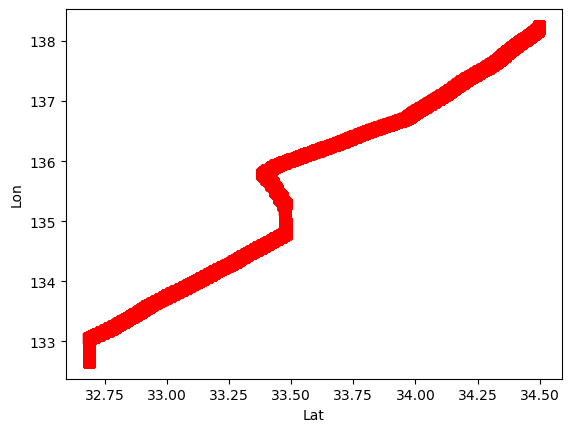

In [101]:
gga.plot.scatter(x='Lat', y='Lon',
                marker='s', c='r', s=50, alpha=0.5)

## 偏流の計算

## LatLonで動いていないかも確認したほうが良い
## knotの単位確認も忘れずに

In [84]:
time_set = set(gga["DtIdx"])
#各速度の閾値超えたら１０分ぶんのでーた捨てる
#はずれた値のデータも捨てる
min_timeHours = np.min(gga["DtIdx"])
max_timeHours = np.max(gga["DtIdx"])
num_timeHours = max_timeHours - min_timeHours + 1

grids0 = []
grids1 = []
curN = []
curE = []
timeHours = []
UTC_time = []
lats = []
lons = []
curN_grid = {}
curE_grid = {}
count_grid = {}
for s in time_set:
    curN_grid[s] = np.zeros(nan_map.shape)
    curE_grid[s] = np.zeros(nan_map.shape)
    count_grid[s] = np.zeros(nan_map.shape) 


for time in time_set:
        # 時間ごとの平均で偏流を求める
        gga1 = gga[time == gga["DtIdx"]]
        vbw1 = vbw[time == vbw["DtIdx"]]
        hdt1 = hdt[time == hdt["DtIdx"]]
        vtg1 = vtg[time == vtg["DtIdx"]]
        if (len(vbw1)==0 or len(gga)==0 or len(hdt1)==0 or len(vtg1)==0):
            continue
        
        # GGAからLat Lon 取得
        lat1 = np.mean(gga1["Lat"])
        lon1 = np.mean(gga1["Lon"])

        # HDTから船首方位取得
        head_rat = deg_to_rat(np.mean(hdt1["HeadDeg"]))
        # VBWから対船水速取得
        water_speed = np.mean(vbw1["LonWaterSpeed"].values)
        
        # VTGから船首方位・対地船速取得
        g_head_rat = deg_to_rat(np.mean(vtg1["HeadDeg"])) #FIXME min 
        ground_speed = np.mean(vtg1["GroundSpeed"])

        
        # 偏流の計算
        curN.append(ground_speed*np.sin(g_head_rat) - water_speed*np.sin(head_rat))
        curE.append(ground_speed*np.cos(g_head_rat) - water_speed*np.cos(head_rat))
        
        # Gridの位置計算
        grid0, grid1 = latlon_to_mesh(lat1, lon1)
        
        grids0.append(grid0)
        grids1.append(grid1)
        lats.append(lat1)
        lons.append(lon1)
        
        UTC_time.append(gga1['UTC'].values[-1][:-6])
        timeHours.append(time)
        curN_grid[time][grid0][grid1] += curN[-1]
        curE_grid[time][grid0][grid1] += curE[-1]

grid_cur = pd.DataFrame([])
grid_cur["DtIdx"] = timeHours
grid_cur["UTC"] = UTC_time
grid_cur["CurN"] = curN
grid_cur["CurE"] = curE
grid_cur["Grid0"] = grids0
grid_cur["Grid1"] = grids1
grid_cur["Lat"] = lats
grid_cur["Lon"] = lons


In [85]:
grid_cur = grid_cur.sort_values('DtIdx')
grid_cur = grid_cur.reset_index(drop=True)


In [86]:
# 各時間のデータ数
grid_cur

,DtIdx,UTC,CurN,CurE,Grid0,Grid1,Lat,Lon
0,-9,2015/12/29 15,0.326853,-0.316020,560,766,34.498972,138.251389
1,-8,2015/12/29 16,0.626643,-0.093699,561,761,34.469943,138.123993
2,-7,2015/12/29 17,1.078720,0.383395,563,752,34.389994,137.878480
3,-6,2015/12/29 18,1.028087,0.223292,566,743,34.315431,137.636532
4,-5,2015/12/29 19,1.210848,-0.480791,569,735,34.222711,137.403786
5,-4,2015/12/29 20,0.508732,0.030742,573,726,34.131349,137.155487
6,-3,2015/12/29 21,0.746386,0.395350,576,717,34.031604,136.898833
7,-2,2015/12/29 22,0.956945,0.593134,581,708,33.912895,136.645989
8,-1,2015/12/29 23,0.740309,0.318861,586,700,33.767048,136.428620
9,0,2015/12/30 0,0.175098,0.037645,593,689,33.564297,136.117906


## データの保存

In [87]:
# 保存
save_path = osp.join(path_log, "cur_hours.csv")
grid_cur.to_csv(save_path)
print(save_path)

./data/shipLog/中春\cur_hours.csv


In [88]:
pkl.dump(curN_grid, open(osp.join(path_log, "curGridN_hours.pkl"), 'wb'))
pkl.dump(curE_grid, open(osp.join(path_log, "curGridE_hours.pkl"), 'wb'))

In [89]:
# 保存
keys = grid_cur.keys()
out = {}
for k in keys:
    out[k] = grid_cur[k]

pkl.dump(out, open(osp.join(path_log, "cur.pkl"), 'wb'))

In [90]:
pkl.dump(grid_cur, open(osp.join(path_log, "cur2.pkl"), 'wb'))